# This project performs Exploratory Data Analysis (EDA) on a student performance dataset.The goal is to analyze how different factors such as study hours, attendance, and parenteducation influence student scores. Various visualizations are created using Matplotlibto understand patterns and relationships in the data.

# Student Performance Analysis

## Basics

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [93]:
df=pd.read_csv('Student_Performance.csv')

#### How many rows and columns are present in the dataset?


In [94]:
df.shape

(25000, 16)

#### What are the data types of each column?

In [95]:
df.dtypes

student_id                 int64
age                        int64
gender                       str
school_type                  str
parent_education             str
study_hours              float64
attendance_percentage    float64
internet_access              str
travel_time                  str
extra_activities             str
study_method                 str
math_score               float64
science_score            float64
english_score            float64
overall_score            float64
final_grade                  str
dtype: object

#### Are there any missing values in the dataset?

In [96]:
df.isnull().sum()


student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

#### What are the basic statistics of numerical columns ?


In [97]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


#### Do any columns have incorrect data types?


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

## Data Cleaning

#### Are there any duplicate rows?

In [99]:
df=df.drop_duplicates()
df.duplicated().sum()



np.int64(0)

#### Make the realistic values of all columns

In [100]:
df=df[(df['age']>=10)&(df['age']<=20)]
df=df[(df['study_hours']>=0)&(df['study_hours']<=24)]
df=df[(df['attendance_percentage']>=0)&(df['attendance_percentage']<=100)]
df=df[(df['overall_score']>=0)&(df['overall_score']<=100)]
df=df[(df['math_score']>=0)&(df['math_score']<=100)]
df=df[(df['science_score']>=0)&(df['science_score']<=100)]
df=df[(df['english_score']>=0)&(df['english_score']<=100)]

## Data Visualization

## Score Distribution Analysis (Using Histograms)

### Histograms are used when question asked about Distribution, Spread, Range, Frequency ,

#### What is the distribution of math scores?

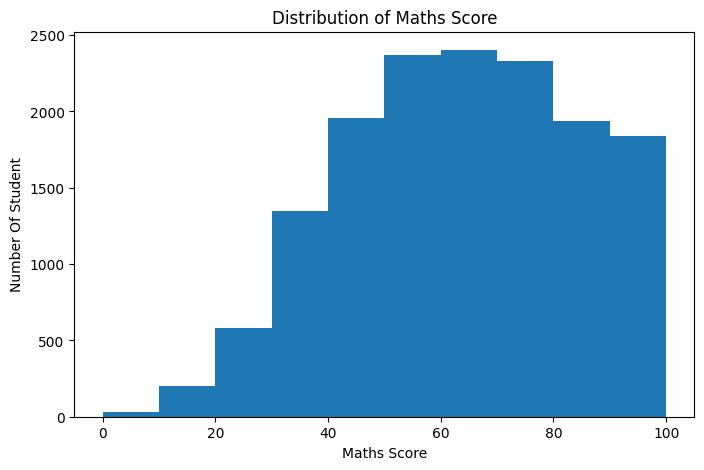

In [101]:
df['math_score'].plot(kind='hist',bins=10,figsize=(8,5))
plt.title("Distribution of Maths Score")
plt.xlabel("Maths Score")
plt.ylabel("Number Of Student")
plt.show()

#### Insight-The maximum number of student fall in the range of 60 to 70 and minimum number of student fall in the range of 0 to 10.

#### What is the distribution of science scores?

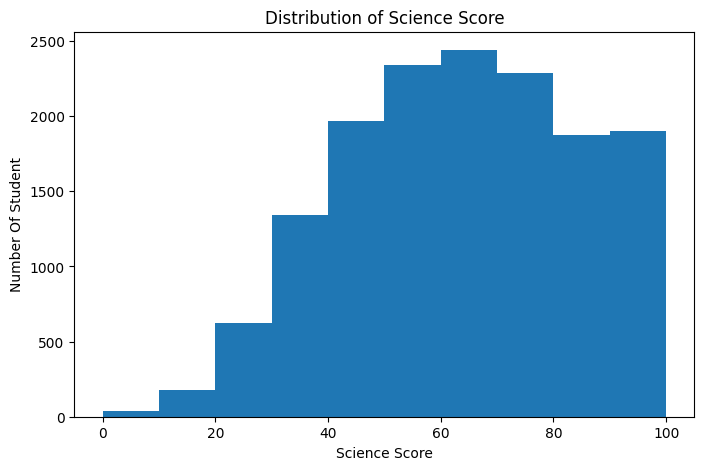

In [102]:
df['science_score'].plot(kind='hist',bins=10,figsize=(8,5))
plt.title("Distribution of Science Score")
plt.xlabel("Science Score")
plt.ylabel("Number Of Student")
plt.show()

#### Insight-The maximum number of student fall in the range of 60 to 70 and minimum number of student fall in the range of 0 to 10.

#### What is the distribution of overall scores?

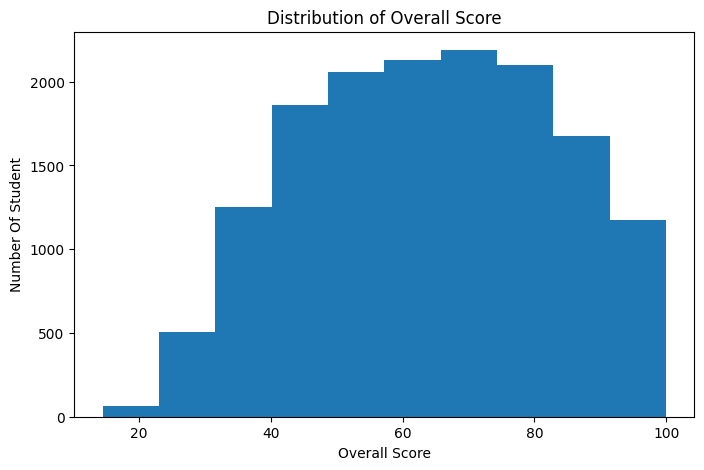

In [103]:
df['overall_score'].plot(kind='hist',bins=10,figsize=(8,5))
plt.title("Distribution of Overall Score")
plt.xlabel("Overall Score")
plt.ylabel("Number Of Student")
plt.show()

#### Insight-The maximum number of student fall in the range of 65.8 to 74.35 and minimum number of student fall in the range of 14.413 to 23.05.

#### In which score range do most students fall?

In [104]:
df['overall_score'].value_counts(bins=10)

(65.8, 74.35]      2189
(57.25, 65.8]      2128
(74.35, 82.9]      2126
(48.7, 57.25]      2033
(40.15, 48.7]      1884
(82.9, 91.45]      1645
(31.6, 40.15]      1241
(91.45, 100.0]     1175
(23.05, 31.6]       513
(14.413, 23.05]      66
Name: count, dtype: int64

## Subject Performance Comparison (Using Bar Graphs)

### Bar graphs are used when question asked about Compare, Average by category, Difference between groups

#### What is the average score in each subject?

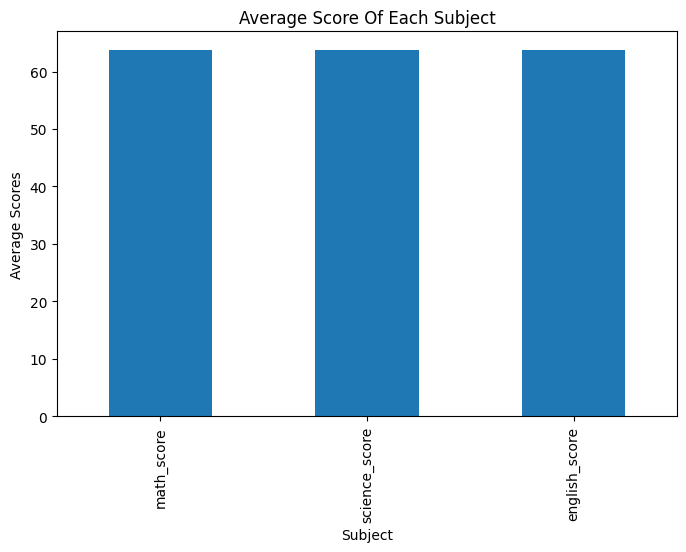

In [105]:
average=df[['math_score','science_score','english_score']].mean()
average.plot(kind='bar',figsize=(8,5))
plt.title("Average Score Of Each Subject")
plt.xlabel("Subject")
plt.ylabel("Average Scores")
plt.show()

#### Insight- Here the highest average is in Maths and lowest average is in English.

#### Which subject has the highest average score?

In [106]:
average.idxmax()

'math_score'

#### Which subject has the lowest average score?

In [107]:
average.idxmin()

'english_score'

#### What is the average score of male vs female students?

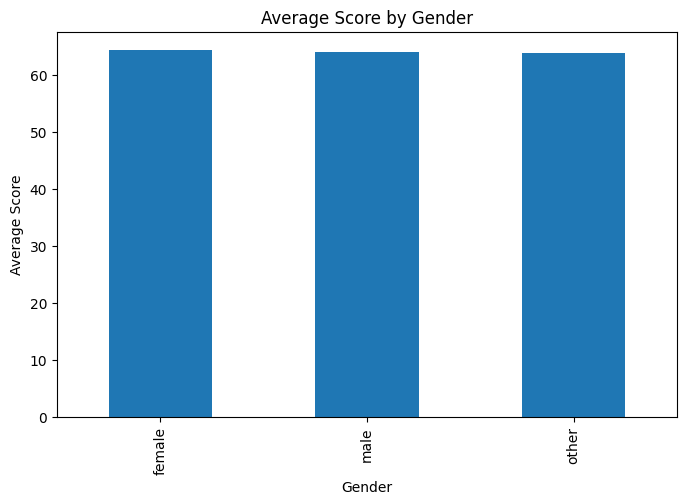

In [108]:
average_score=df.groupby('gender')['overall_score'].mean()
average_score.plot(kind='bar',figsize=(8,5))
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

#### Insight- Here the female gender have highest average score and other gender have minimum average score.

#### Does parent education level influence scores?

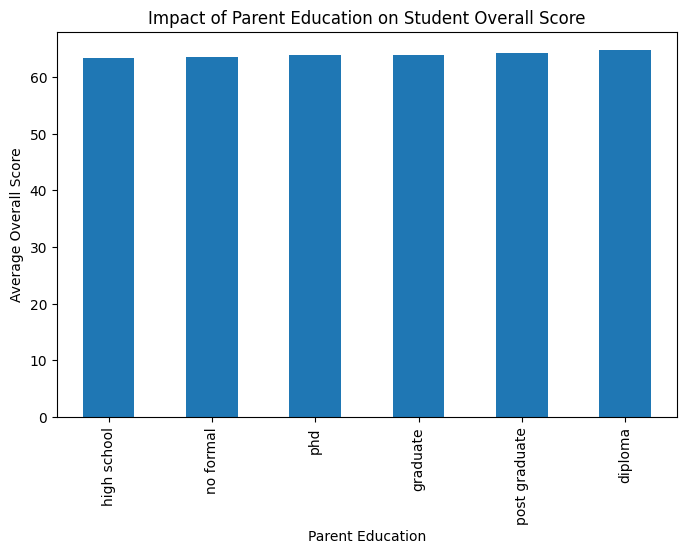

In [109]:
df.groupby('parent_education')['overall_score'].mean().sort_values().plot(kind='bar',figsize=(8,5))
plt.title("Impact of Parent Education on Student Overall Score")
plt.xlabel("Parent Education")
plt.ylabel("Average Overall Score")
plt.show()

#### Insight-Students whose parents had done 'diploma' tend to achieve higher average overall scores.

#### Does school type affect overall performance?

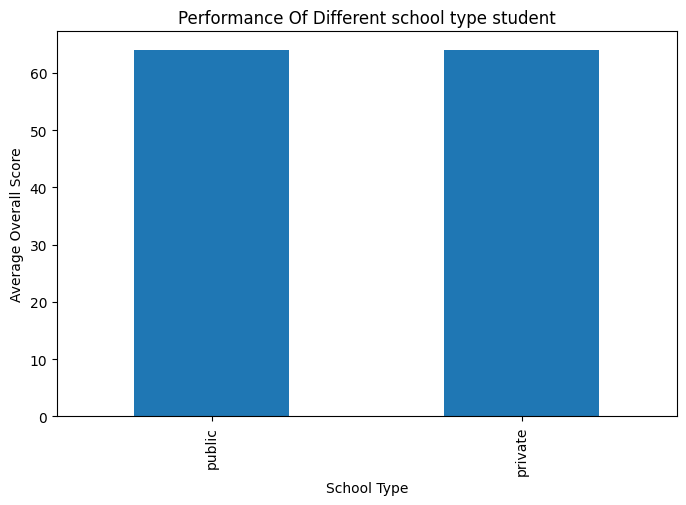

In [110]:
df.groupby('school_type')['overall_score'].mean().sort_values().plot(kind='bar',figsize=(8,5))
plt.title("Performance Of Different school type student")
plt.xlabel("School Type")
plt.ylabel("Average Overall Score")
plt.show()

#### Insight-Student of Private School had better average score than the student of Public School.

#### 

## Study Behavior Analysis (Using Scatter Plot)

### Scatter plot are used when question asked about relationship, correlation, impact, effect, association

#### Is there a relationship between study hours and overall score?

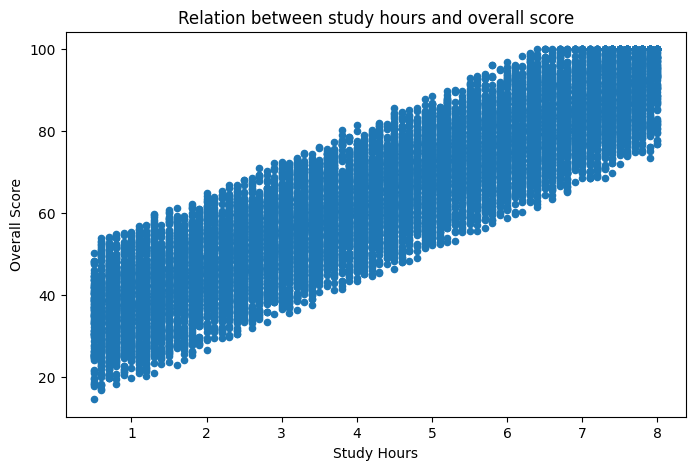

In [111]:
df.plot(kind='scatter',y='overall_score',x='study_hours',figsize=(8,5))
plt.title("Relation between study hours and overall score")
plt.ylabel("Overall Score")
plt.xlabel("Study Hours")
plt.show()

#### Insight- This clearly tell that the student that have more study hours had perform well in overall score.

#### Is the relationship strong or weak?

In [112]:
df[['study_hours','overall_score']].corr()


,study_hours,overall_score
study_hours,1.000000,0.905885
overall_score,0.905885,1.000000


#### Does attendance percentage affect performance?

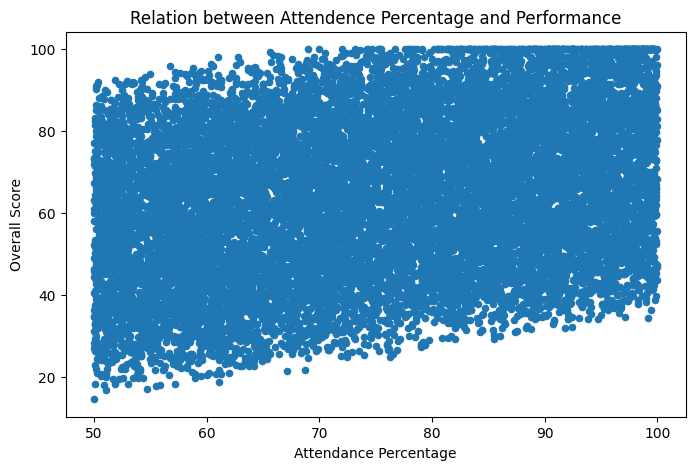

In [113]:
df.plot(kind='scatter',x='attendance_percentage',y='overall_score',figsize=(8,5))
plt.title("Relation between Attendence Percentage and Performance")
plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")
plt.show()

#### Insight-The student having more attendance has a good academic score.

## Attendance Impact (Using Line Graphs)

### Line graphs are used when question asked trend, pattern, increase or decrease

#### How does the average overall score change as study hours increase?

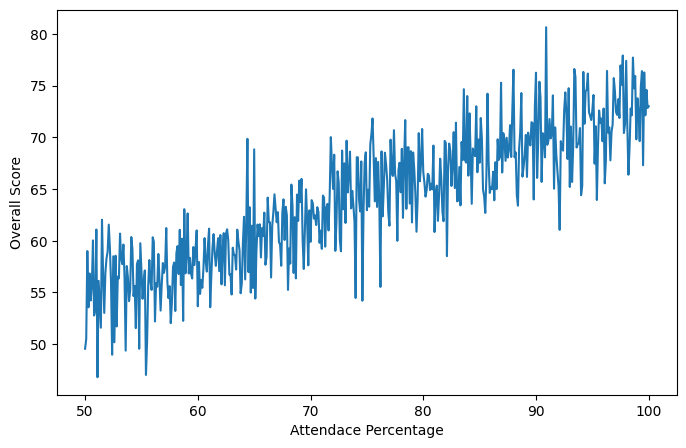

In [114]:
avg_score = df.groupby('attendance_percentage')['overall_score'].mean()
avg_score.plot(kind='line', figsize=(8,5))
plt.xlabel("Attendace Percentage")
plt.ylabel("Overall Score")
plt.show()

#### Insight-As the increase in attendance percentage Overall score also increase.

## Grade Distribution (Using Pie Charts)

### Pie charts are used when question asked percentage, proportion, share, distribution of categories


#### What percentage of students fall into each final grade category?

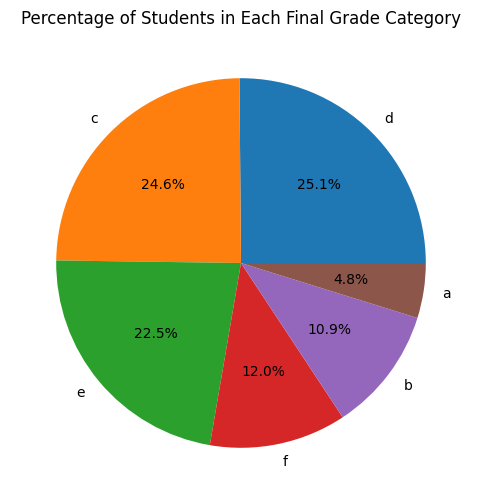

In [115]:
df['final_grade'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title("Percentage of Students in Each Final Grade Category")
plt.show()

#### Insight-Maximum student have 'd' grade and minimum of them have 'a' grade.

#### Which grade category has the largest proportion of students?

In [116]:
df['final_grade'].value_counts().idxmax()

'd'

## Correlation (Using Heatmap)

### Heatmap is used when question ask Correlations between variables, Strength of relationships, Matrix-type data.

#### What is the distribution of overall student scores and are there any outliers?

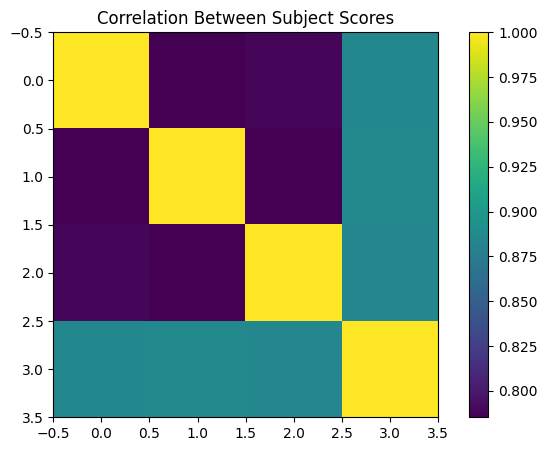

In [117]:
plt.figure(figsize=(8,5))
plt.imshow(df[['math_score','science_score','english_score','overall_score']].corr())
plt.colorbar()
plt.title("Correlation Between Subject Scores")
plt.show()

#### Insight-The heatmap shows strong positive correlations between math, science and english scores. This suggests that students who perform well in one subject tend to perform well in others.